# Random Forest Classifier
## Dataset: Data Bantal
Notebook ini membangun model Random Forest untuk memprediksi apakah konsumen menyukai produk bantal premium berdasarkan fitur demografi dan preferensi.

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 1. Load Dataset

In [37]:
df = pd.read_csv('../dataset/data_bantal.csv')
df

,ID,Nama Product,Jenis Kelamin,Usia,Harga,Desain,Kenyamanan,Durasi Tidur,Random Forest,Grad. Boosting,Naive Bayes,K-Means,Kesimpulan
0,INSERT INTO data_preferensi (nama,jenis_kelamin,usia,harga,desain,kenyamanan,durasi_tidur,random_forest,gradient_boosting,naive_bayes,kmeans_cluster,kesimpulan) VALUES,NaN
1,('Kece Series','P',23,4,3,1,10,0,1,1,2,'Direkomendasikan'),
2,('Kece Series','L',26,3,5,3,9,0,0,0,2,'Cukup Direkomendasikan'),NaN
3,('Premium Series','P',22,1,3,4,4,0,0,0,1,'Cukup Direkomendasikan'),NaN
4,('Kece Series','P',45,5,4,3,7,0,1,1,3,'Direkomendasikan'),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,('Kids Signature Series','P',55,2,5,2,5,0,1,0,1,'Cukup Direkomendasikan'),NaN
297,('Signature Series','L',52,4,4,5,10,0,0,0,3,'Cukup Direkomendasikan'),NaN
298,('Kece Series','L',46,5,1,4,5,1,0,0,3,'Cukup Direkomendasikan'),NaN
299,('Deluxe Series','P',54,5,2,2,7,1,1,0,2,'Direkomendasikan'),NaN


In [38]:
df.head()

,ID,Nama Product,Jenis Kelamin,Usia,Harga,Desain,Kenyamanan,Durasi Tidur,Random Forest,Grad. Boosting,Naive Bayes,K-Means,Kesimpulan
0,INSERT INTO data_preferensi (nama,jenis_kelamin,usia,harga,desain,kenyamanan,durasi_tidur,random_forest,gradient_boosting,naive_bayes,kmeans_cluster,kesimpulan) VALUES,NaN
1,('Kece Series','P',23,4,3,1,10,0,1,1,2,'Direkomendasikan'),
2,('Kece Series','L',26,3,5,3,9,0,0,0,2,'Cukup Direkomendasikan'),NaN
3,('Premium Series','P',22,1,3,4,4,0,0,0,1,'Cukup Direkomendasikan'),NaN
4,('Kece Series','P',45,5,4,3,7,0,1,1,3,'Direkomendasikan'),NaN


## 2. Preprocessing & Feature Engineering

In [39]:
# Bersihkan nama kolom
df.columns = df.columns.str.strip()

# Paksa kolom numerik
df['Harga'] = pd.to_numeric(df['Harga'], errors='coerce')
df['Desain'] = pd.to_numeric(df['Desain'], errors='coerce')
df['Kenyamanan'] = pd.to_numeric(df['Kenyamanan'], errors='coerce')

# Isi data kosong hasil konversi
df = df.fillna(0)

# Encode kolom kategori
le = LabelEncoder()
df['Jenis Kelamin'] = le.fit_transform(df['Jenis Kelamin'])

# Buat target: suka produk premium jika Harga + Desain + Kenyamanan >= 12
df['suka_premium'] = (
    (df['Harga'] + df['Desain'] + df['Kenyamanan']) >= 12
).astype(int)

df['Durasi Tidur'].value_counts()

Durasi Tidur
1                 157
0                 143
 random_forest      1
Name: count, dtype: int64

## 3. Fitur dan Target

In [40]:
X = df[['Jenis Kelamin', 'Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']]
y = df['suka_premium']

print("Shape X:", X.shape)
print("Distribusi y:", y.value_counts().to_dict())

Shape X: (301, 6)
Distribusi y: {1: 196, 0: 105}


## 4. Split Data

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (240, 6), Test: (61, 6)


## 5. Training Model Random Forest

In [42]:
X_train.select_dtypes(include='object').head()
y_train.value_counts()
X_train.nunique()

Jenis Kelamin    43
Usia              6
Harga             6
Desain            6
Kenyamanan        8
Durasi Tidur      3
dtype: int64

In [43]:
df.columns = df.columns.str.strip()

# bersihkan spasi di data kategori
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# =========================
# 2. SPLIT FEATURE & TARGET
# =========================

X = df.drop('Durasi Tidur', axis=1)
y = df['Durasi Tidur']

# =========================
# 3. ENCODING (UBAH TEKS → ANGKA)
# =========================

X = pd.get_dummies(X)

# =========================
# 4. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================
# 5. MODEL RANDOM FOREST
# =========================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 6. OUTPUT
# =========================

print("✅ Model berhasil dilatih!")
print("Akurasi Training:", model.score(X_train, y_train))
print("Akurasi Testing:", model.score(X_test, y_test))

✅ Model berhasil dilatih!
Akurasi Training: 1.0
Akurasi Testing: 0.7377049180327869


## 6. Prediksi

In [44]:
y_pred = model.predict(X_test)

## 7. Evaluasi Model

Akurasi : 0.7377049180327869

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.69      0.73        32
           1       0.70      0.79      0.74        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



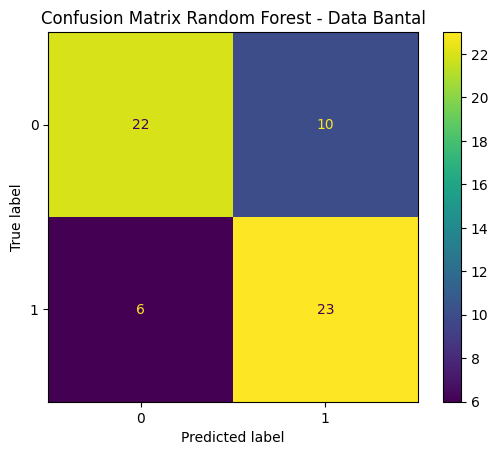

In [45]:
print('Akurasi :', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix Random Forest - Data Bantal')
plt.show()

## 8. Visualisasi Pohon Keputusan

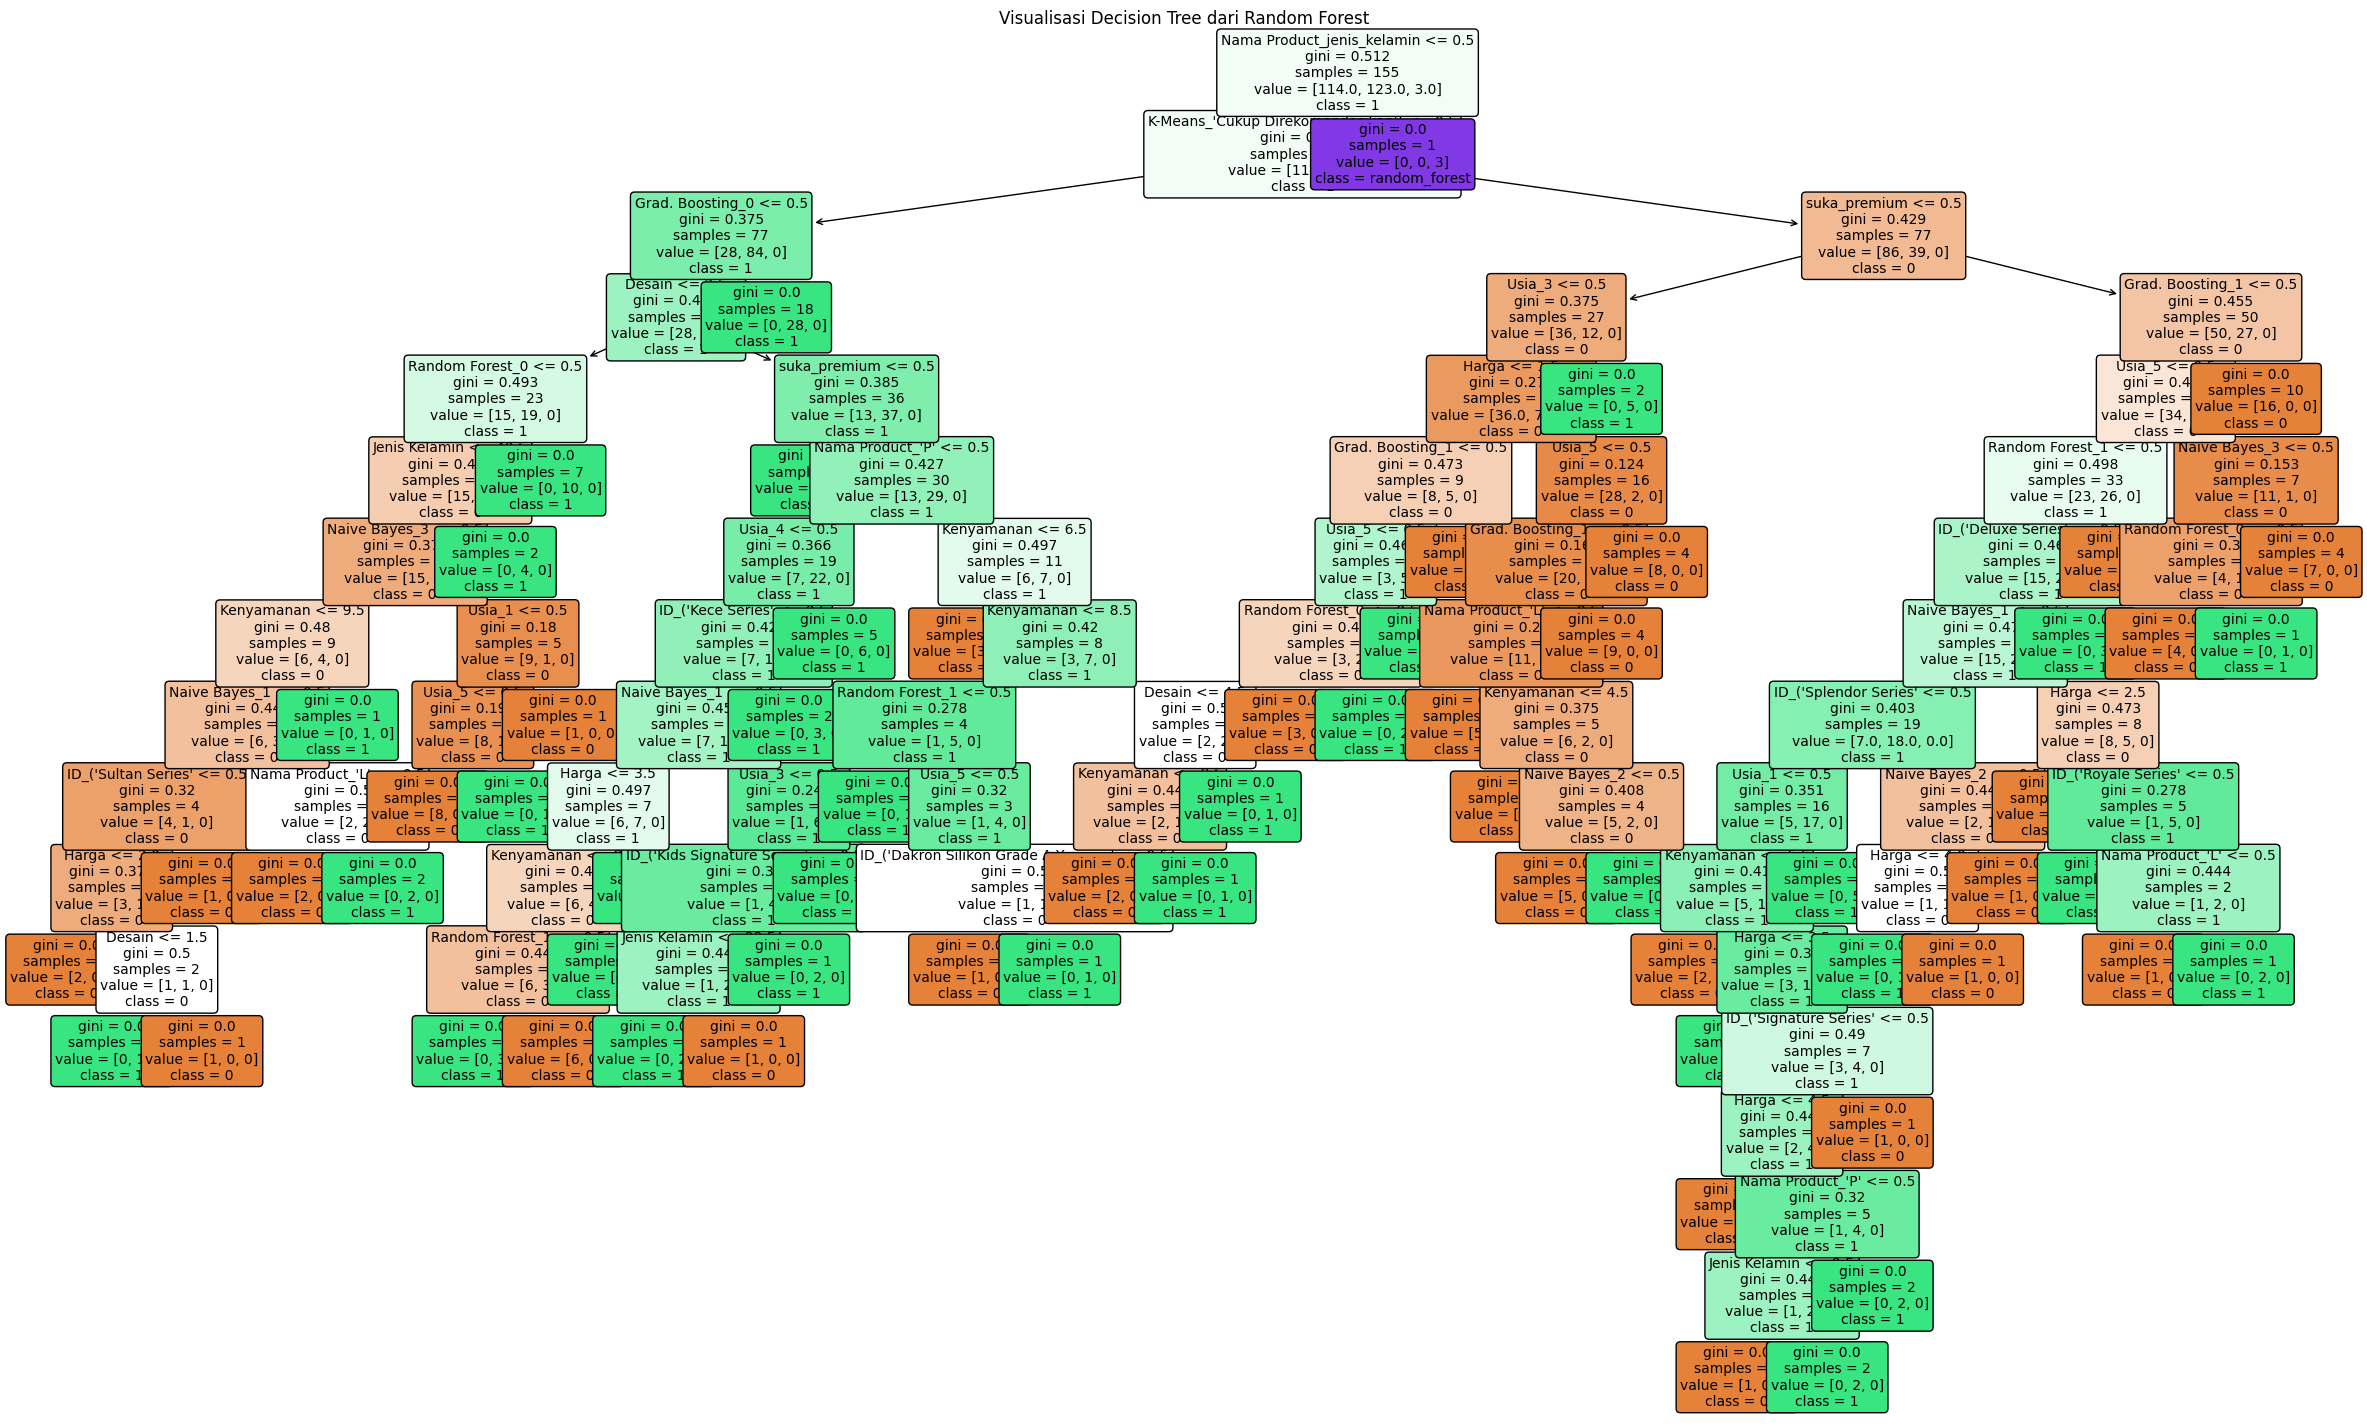

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = model.estimators_[0]

plt.figure(figsize=(30, 18))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],  # 🔥 FIX UTAMA
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Visualisasi Decision Tree dari Random Forest')
plt.show()

## 9. Prediksi Data Baru

In [47]:

# data baru HARUS dibuat dataframe dengan kolom yang sama
data_baru = pd.DataFrame([[0, 24, 4, 5, 5, 7]], columns=[
    'jenis_kelamin', 'usia', 'harga', 'desain', 'kenyamanan', 'durasi_tidur'
])

# samakan encoding seperti training
data_baru = pd.get_dummies(data_baru)

# samakan dengan fitur training
data_baru = data_baru.reindex(columns=X.columns, fill_value=0)

# prediksi
pred_baru = model.predict(data_baru)

print('Prediksi:', pred_baru[0])
print('Keterangan:', 'Menyukai Produk Premium' if pred_baru[0] == 1 else 'Tidak Menyukai Premium')

Prediksi: 0
Keterangan: Tidak Menyukai Premium


## 10. Kesimpulan

In [48]:
akurasi = accuracy_score(y_test, y_pred)

print('\n==================== KESIMPULAN ====================')
print(f'Akurasi Model Random Forest : {akurasi*100:.2f}%')
print('Model mampu mengklasifikasikan apakah konsumen menyukai produk bantal premium')
print('berdasarkan fitur: jenis kelamin, usia, harga, desain, kenyamanan, durasi tidur.')

if akurasi > 0.85:
    print('Model memiliki performa SANGAT BAIK dan dapat digunakan untuk prediksi preferensi.')
elif akurasi > 0.75:
    print('Model memiliki performa BAIK namun masih bisa ditingkatkan.')
else:
    print('Model kurang akurat, perlu tuning parameter atau menambah data.')

print('====================================================')


==================== KESIMPULAN ====================
Akurasi Model Random Forest : 73.77%
Model mampu mengklasifikasikan apakah konsumen menyukai produk bantal premium
berdasarkan fitur: jenis kelamin, usia, harga, desain, kenyamanan, durasi tidur.
Model kurang akurat, perlu tuning parameter atau menambah data.


## 11. Simpan Model

In [49]:
import pickle

save_dict = {'model': model}

with open('../flask-app/rf_model.pkl', 'wb') as f:
    pickle.dump(save_dict, f)

print("✅ File 'rf_model.pkl' berhasil dibuat (model saja)")

✅ File 'rf_model.pkl' berhasil dibuat (model saja)
